In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import scipy.stats as stats

In [2]:
from sklearn.model_selection import train_test_split
from sklearn.model_selection import cross_val_score
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score
from sklearn.preprocessing import PowerTransformer

In [3]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("vivekgediya/concrete-data")

print("Path to dataset files:", path)

Path to dataset files: C:\Users\Dir com\.cache\kagglehub\datasets\vivekgediya\concrete-data\versions\1


In [4]:
import os
import pandas as pd

# Import the required libraries before using them
df = pd.read_csv(os.path.join(path, os.listdir(path)[0]))
df.head()

,Cement (component 1)(kg in a m^3 mixture),Blast Furnace Slag (component 2)(kg in a m^3 mixture),Fly Ash (component 3)(kg in a m^3 mixture),Water (component 4)(kg in a m^3 mixture),Superplasticizer (component 5)(kg in a m^3 mixture),Coarse Aggregate (component 6)(kg in a m^3 mixture),Fine Aggregate (component 7)(kg in a m^3 mixture),Age (day),"Concrete compressive strength(MPa, megapascals)"
0,540.0,0.0,0.0,162.0,2.5,1040.0,676.0,28,79.99
1,540.0,0.0,0.0,162.0,2.5,1055.0,676.0,28,61.89
2,332.5,142.5,0.0,228.0,0.0,932.0,594.0,270,40.27
3,332.5,142.5,0.0,228.0,0.0,932.0,594.0,365,41.05
4,198.6,132.4,0.0,192.0,0.0,978.4,825.5,360,44.30


In [5]:
df.shape

(1030, 9)

In [6]:
df.isnull().sum()

Cement (component 1)(kg in a m^3 mixture)                0
Blast Furnace Slag (component 2)(kg in a m^3 mixture)    0
Fly Ash (component 3)(kg in a m^3 mixture)               0
Water  (component 4)(kg in a m^3 mixture)                0
Superplasticizer (component 5)(kg in a m^3 mixture)      0
Coarse Aggregate  (component 6)(kg in a m^3 mixture)     0
Fine Aggregate (component 7)(kg in a m^3 mixture)        0
Age (day)                                                0
Concrete compressive strength(MPa, megapascals)          0
dtype: int64

In [7]:
df.describe()

,Cement (component 1)(kg in a m^3 mixture),Blast Furnace Slag (component 2)(kg in a m^3 mixture),Fly Ash (component 3)(kg in a m^3 mixture),Water (component 4)(kg in a m^3 mixture),Superplasticizer (component 5)(kg in a m^3 mixture),Coarse Aggregate (component 6)(kg in a m^3 mixture),Fine Aggregate (component 7)(kg in a m^3 mixture),Age (day),"Concrete compressive strength(MPa, megapascals)"
count,1030.000000,1030.000000,1030.000000,1030.000000,1030.000000,1030.000000,1030.000000,1030.000000,1030.000000
mean,281.167864,73.895825,54.188350,181.567282,6.204660,972.918932,773.580485,45.662136,35.817961
std,104.506364,86.279342,63.997004,21.354219,5.973841,77.753954,80.175980,63.169912,16.705742
min,102.000000,0.000000,0.000000,121.800000,0.000000,801.000000,594.000000,1.000000,2.330000
25%,192.375000,0.000000,0.000000,164.900000,0.000000,932.000000,730.950000,7.000000,23.710000
50%,272.900000,22.000000,0.000000,185.000000,6.400000,968.000000,779.500000,28.000000,34.445000
75%,350.000000,142.950000,118.300000,192.000000,10.200000,1029.400000,824.000000,56.000000,46.135000
max,540.000000,359.400000,200.100000,247.000000,32.200000,1145.000000,992.600000,365.000000,82.600000


In [8]:
# try to fix 0 values Problem
x = df.iloc[:, :-1]
y = df.iloc[:, -1]

In [9]:
x_train , x_test , y_train , y_test = train_test_split(x, y , test_size= 0.2 , random_state=42)

In [10]:
#Applying Regression without any transformation
Ir = LinearRegression()
Ir.fit(x_train, y_train)
y_pred = Ir.predict(x_test)
r2_score(y_test , y_pred)

0.6275531792314855

In [11]:
#Cross checking with cross val score
Ir = LinearRegression()
np.mean(cross_val_score(Ir , x ,y , scoring='r2'))

np.float64(0.4609940491662865)

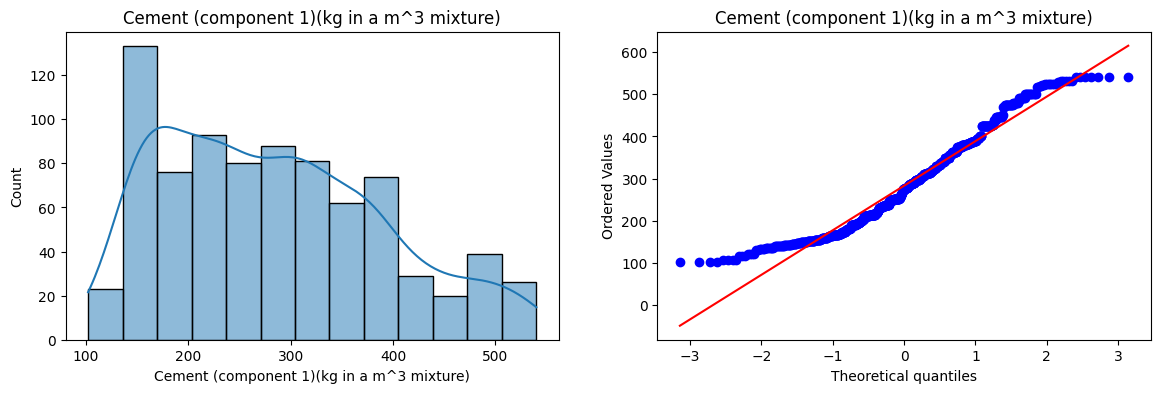

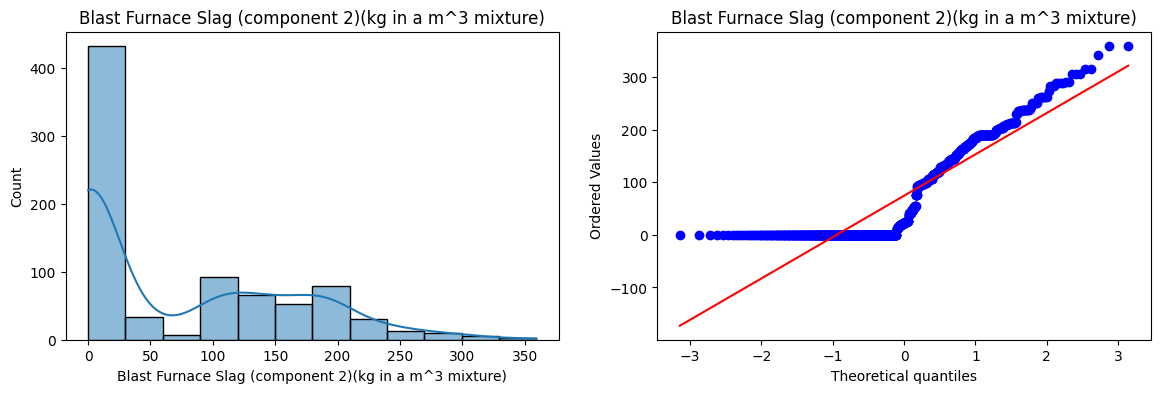

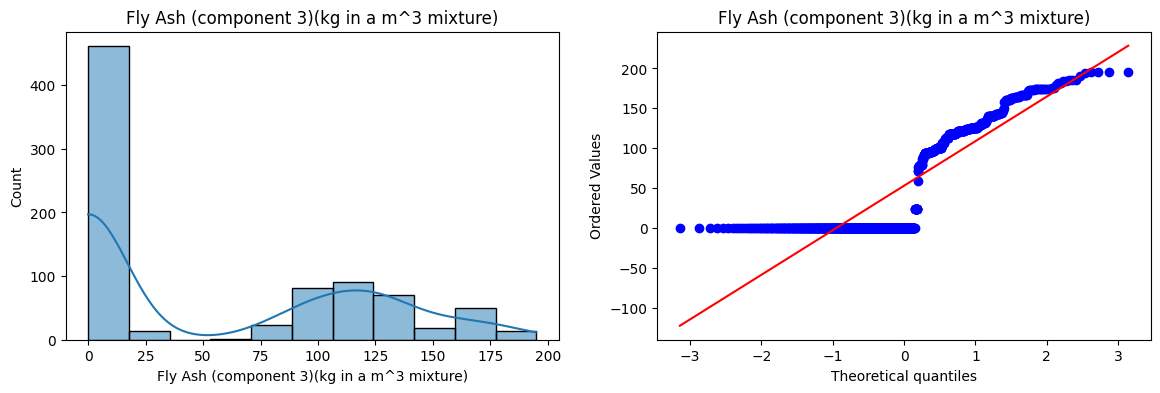

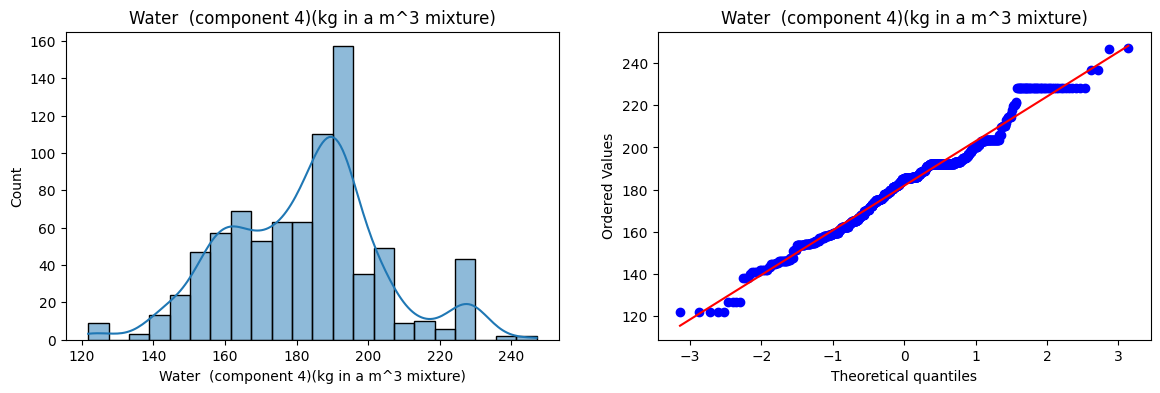

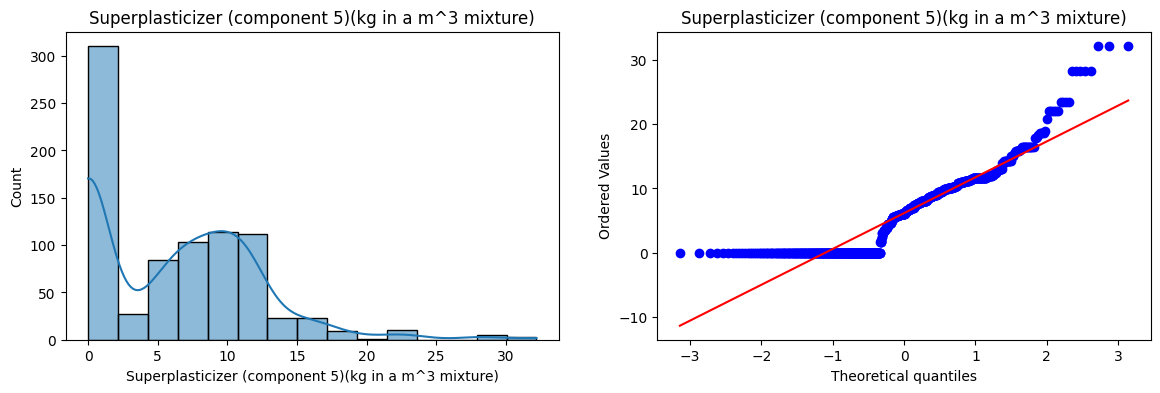

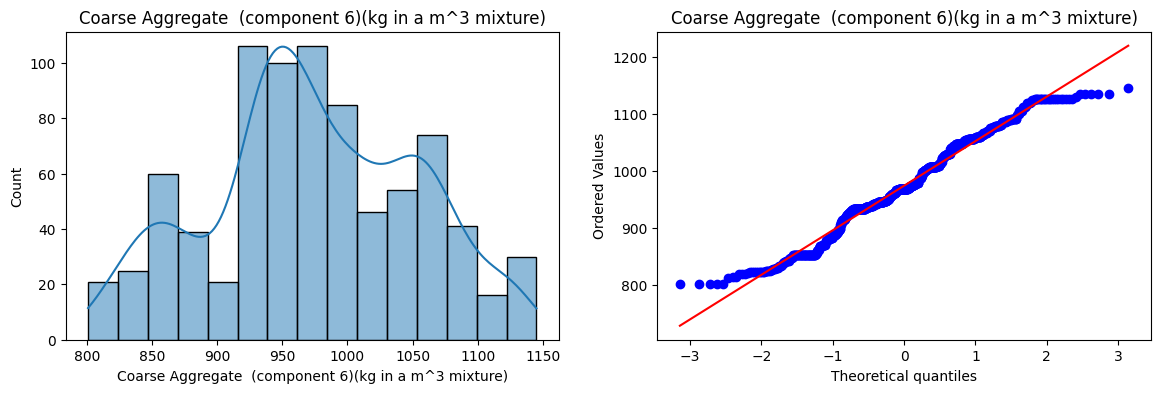

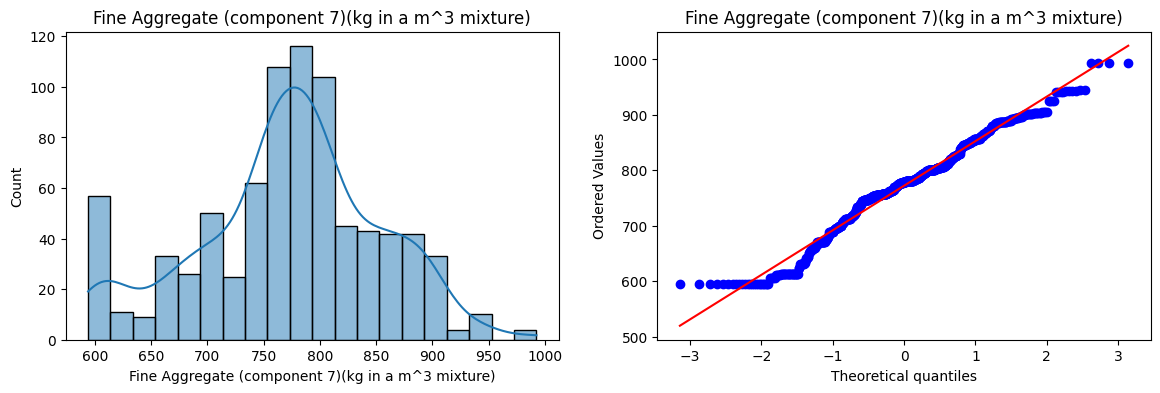

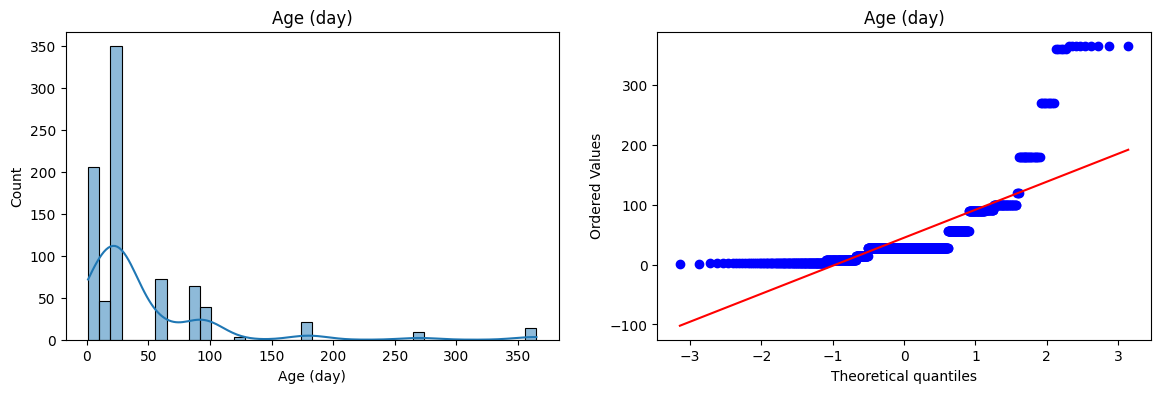

In [12]:
#Plotting the distplots without any transformation
from scipy import stats

for col in x_train.columns:
    plt.figure(figsize=(14, 4))

    plt.subplot(121)
    sns.histplot(x_train[col], kde=True)
    plt.title(col)

    plt.subplot(122)
    stats.probplot(x_train[col], dist="norm", plot=plt)
    plt.title(col)

    plt.show()

In [13]:
#Applying Box-Cox Tranform
pt = PowerTransformer(method='box-cox')

x_train_transformed = pt.fit_transform(x_train + 0.000001)
x_test_transformed = pt.transform(x_test + 0.000001)

pd.DataFrame({
    'col': x_train.columns,
    'box_cox_lambdas': pt.lambdas_
})

,col,box_cox_lambdas
0,Cement (component 1)(kg in a m^3 mixture),0.177025
1,Blast Furnace Slag (component 2)(kg in a m^3 m...,0.025093
2,Fly Ash (component 3)(kg in a m^3 mixture),-0.038970
3,Water (component 4)(kg in a m^3 mixture),0.772682
4,Superplasticizer (component 5)(kg in a m^3 mix...,0.098811
5,Coarse Aggregate (component 6)(kg in a m^3 mi...,1.129813
6,Fine Aggregate (component 7)(kg in a m^3 mixture),1.782018
7,Age (day),0.066631


In [16]:
# Applying linear regression on transformed data
lr = LinearRegression()

lr.fit(x_train_transformed, y_train)

y_pred2 = lr.predict(x_test_transformed)

r2_score(y_test, y_pred2)

0.8047825008078886

In [18]:
# Using cross val score

pt = PowerTransformer(method='box-cox')
x_transformed = pt.fit_transform(x + 0.000001)

lr = LinearRegression()
x_train_transformed = pd.DataFrame(x_train_transformed2 , columns=x_train.columns)
np.mean(cross_val_score(lr, x_transformed, y, scoring='r2'))

np.float64(0.6662950326831084)

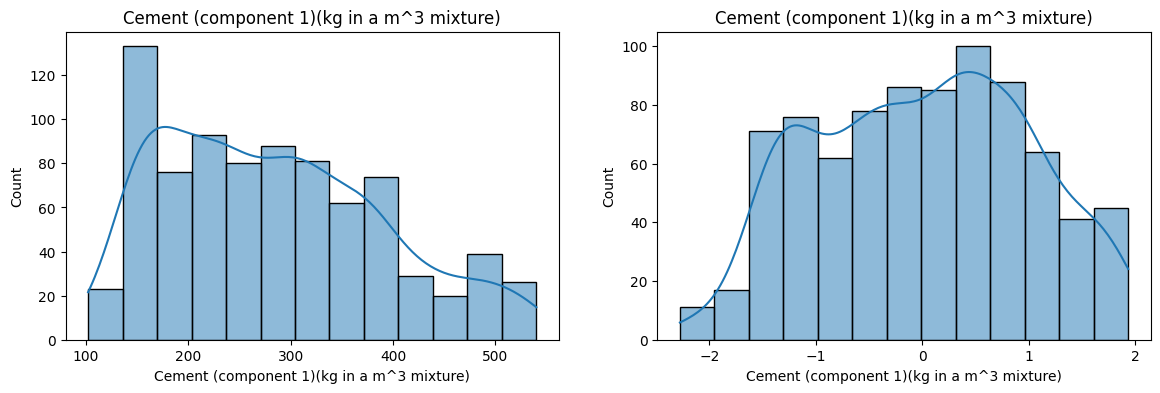

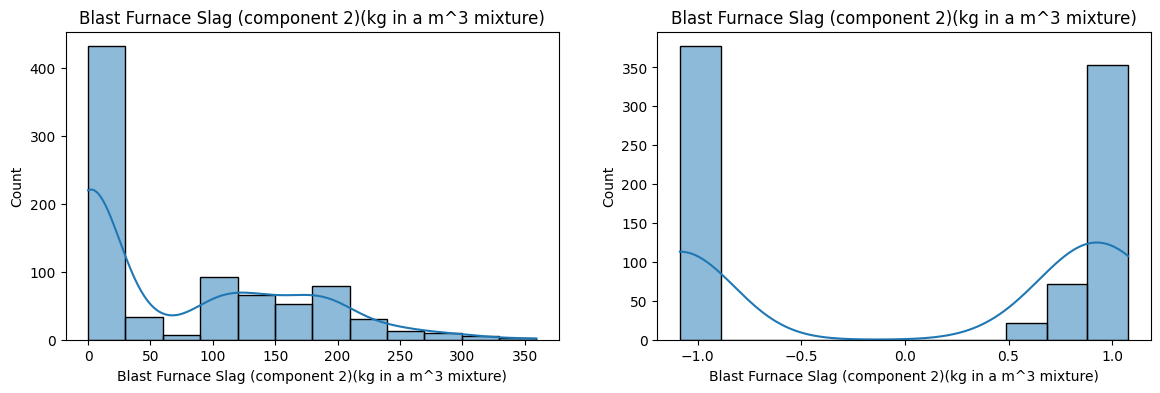

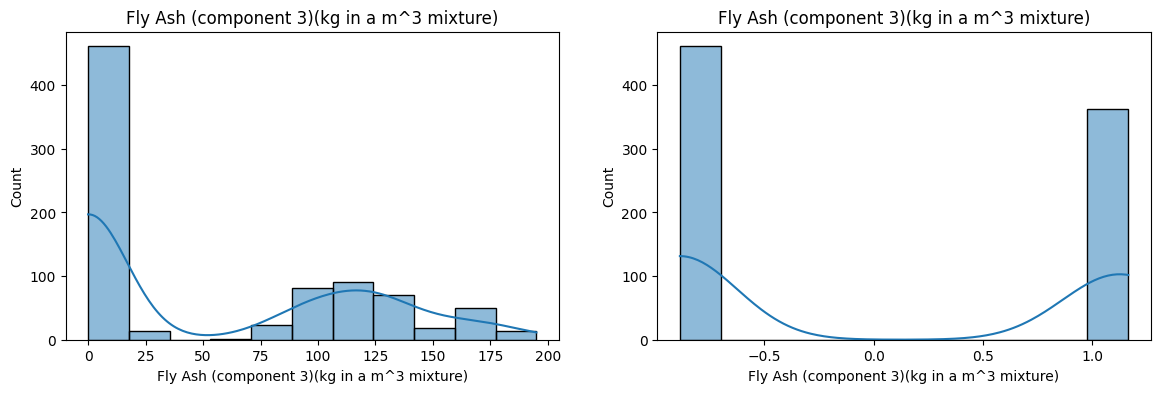

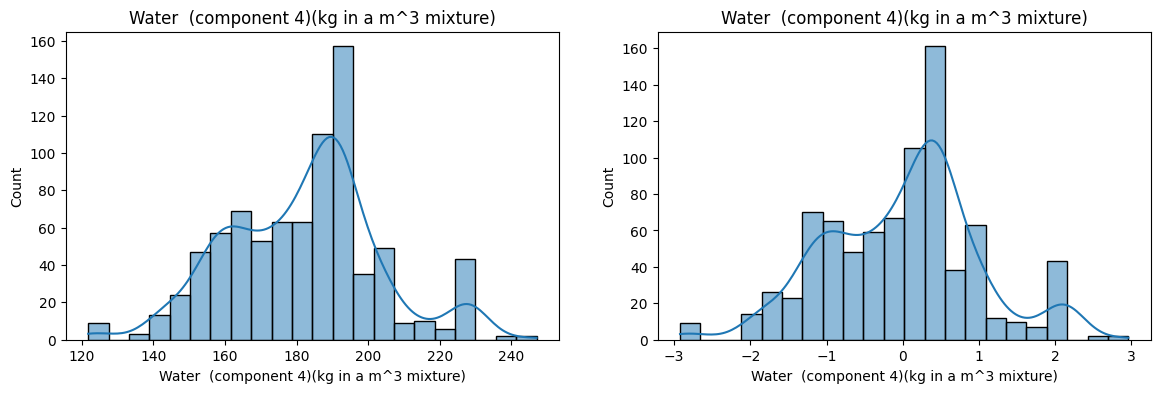

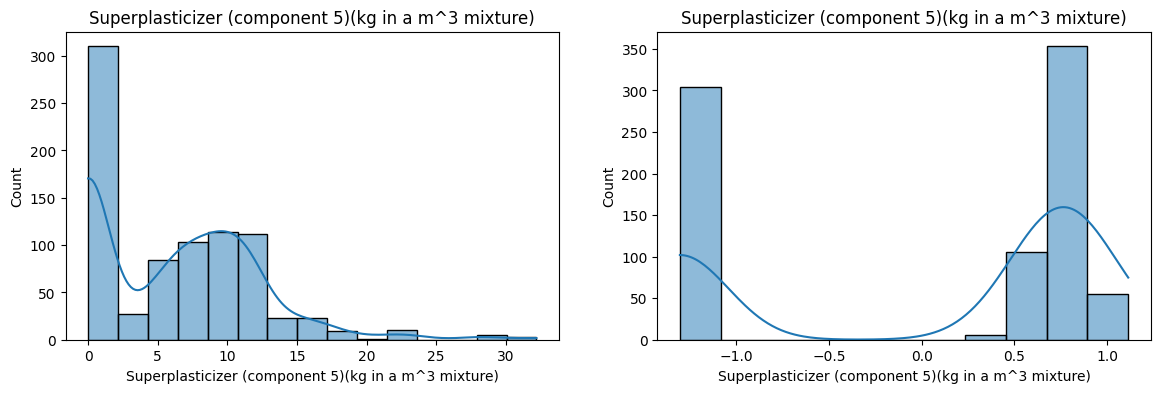

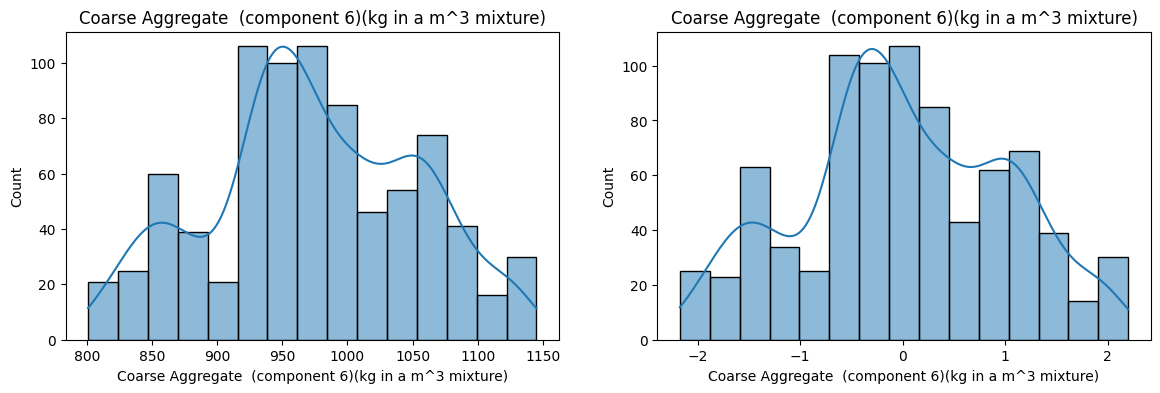

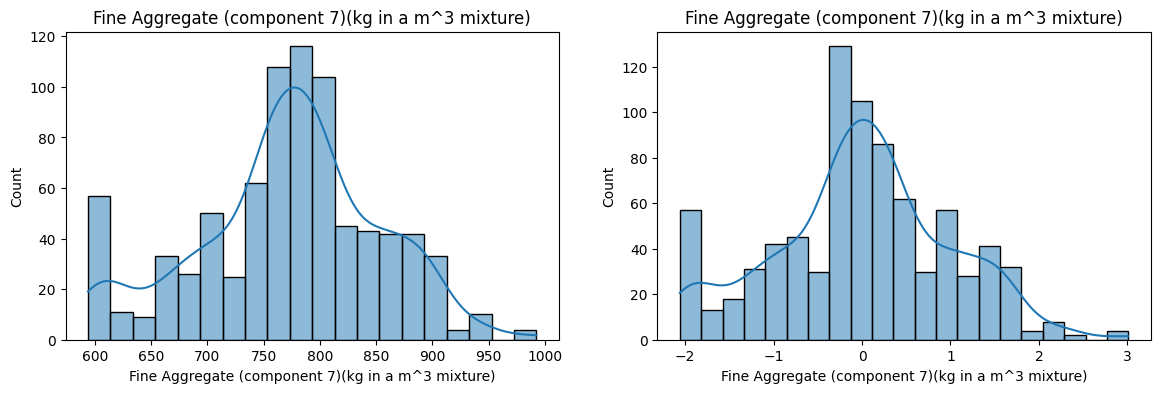

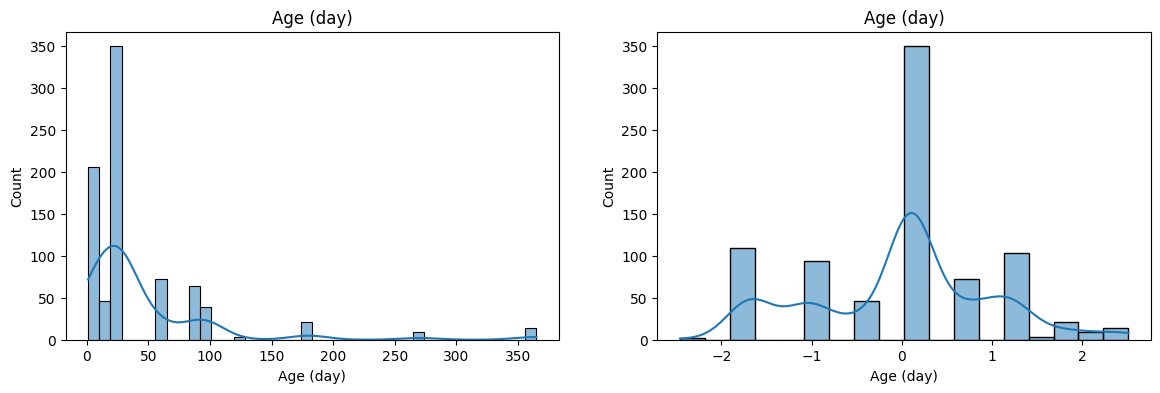

In [28]:
# Before and After comparision for Box_Cox Plot
x_train_transformed = pd.DataFrame(
    x_train_transformed,
    columns=x_train.columns
)

for col in x_train_transformed.columns:
    plt.figure(figsize=(14, 4))

    plt.subplot(121)
    sns.histplot(x_train[col], kde=True)
    plt.title(col)

    plt.subplot(122)
    sns.histplot(x_train_transformed[col], kde=True)
    plt.title(col)

    plt.show()

In [30]:
# Apply Yeo-Johnson Transform
pt1 = PowerTransformer()

x_train_transformed2 = pt1.fit_transform(x_train)
x_test_transformed2 = pt1.transform(x_test)

lr = LinearRegression()
lr.fit(x_train_transformed2, y_train)

y_pred3 = lr.predict(x_test_transformed2)

print(r2_score(y_test, y_pred3))

pd.DataFrame({
    'col': x_train.columns,
    'Yeo_Johnson_lambdas': pt1.lambdas_
})

0.8161906511066098


,col,Yeo_Johnson_lambdas
0,Cement (component 1)(kg in a m^3 mixture),0.174348
1,Blast Furnace Slag (component 2)(kg in a m^3 m...,0.015715
2,Fly Ash (component 3)(kg in a m^3 mixture),-0.161447
3,Water (component 4)(kg in a m^3 mixture),0.771307
4,Superplasticizer (component 5)(kg in a m^3 mix...,0.253935
5,Coarse Aggregate (component 6)(kg in a m^3 mi...,1.130050
6,Fine Aggregate (component 7)(kg in a m^3 mixture),1.783100
7,Age (day),0.019885


In [32]:
# Using cross val score

pt = PowerTransformer()
x_transformed2 = pt.fit_transform(x)

lr = LinearRegression()
np.mean(cross_val_score(lr, x_transformed2, y, scoring='r2'))

np.float64(0.6834625126992433)

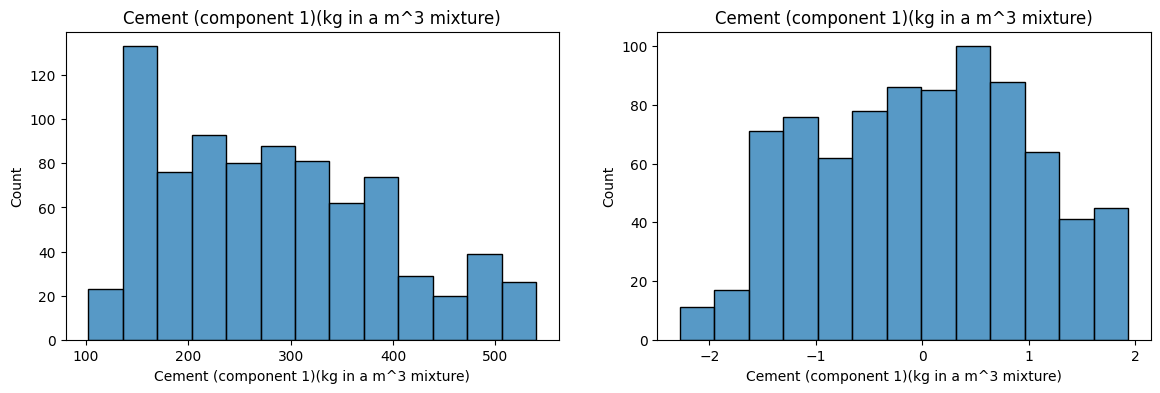

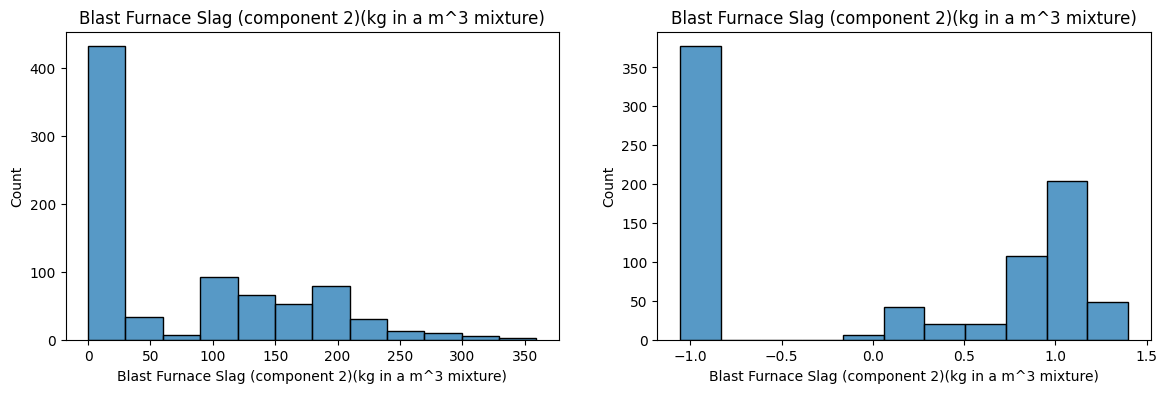

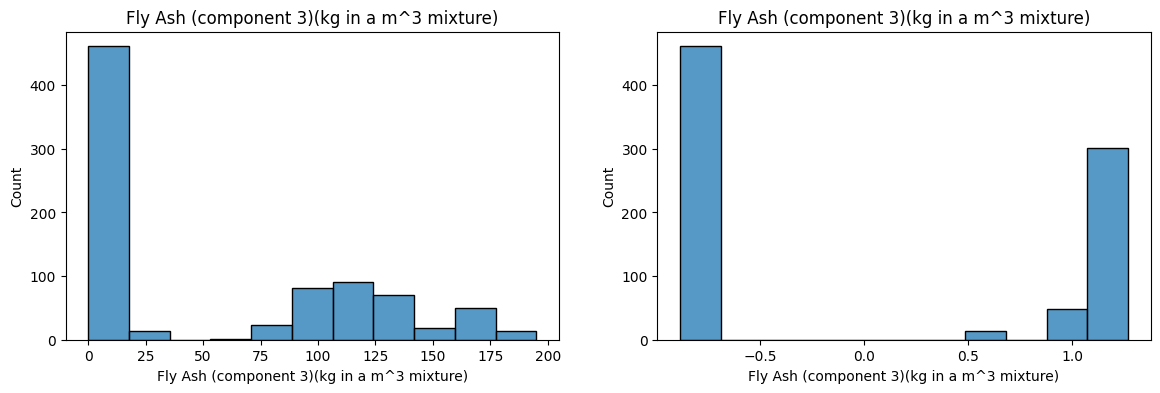

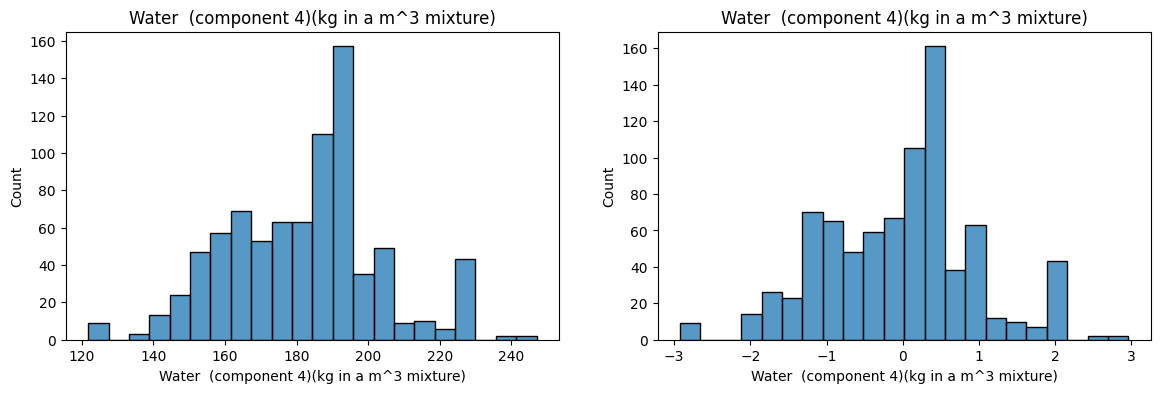

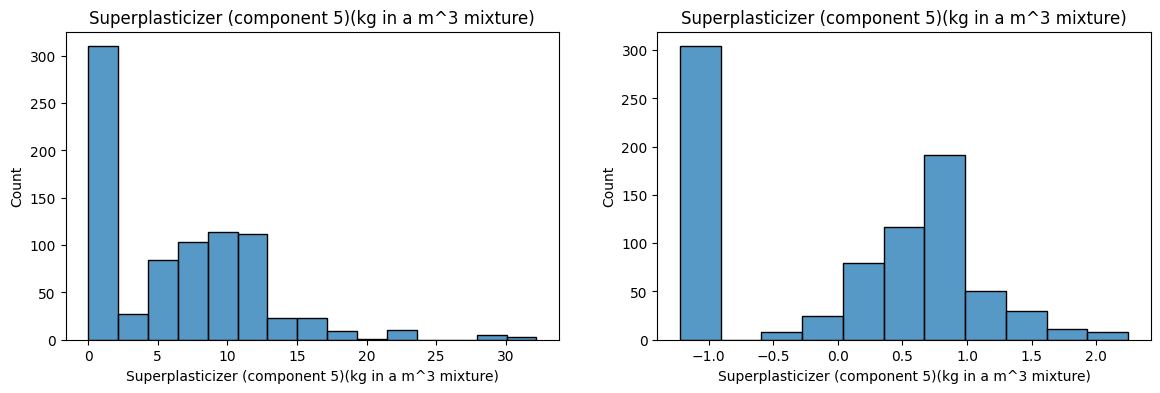

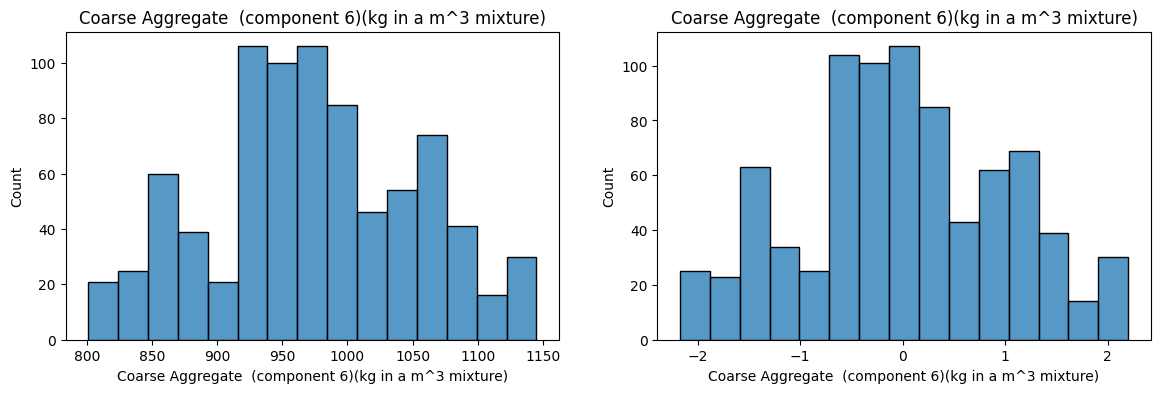

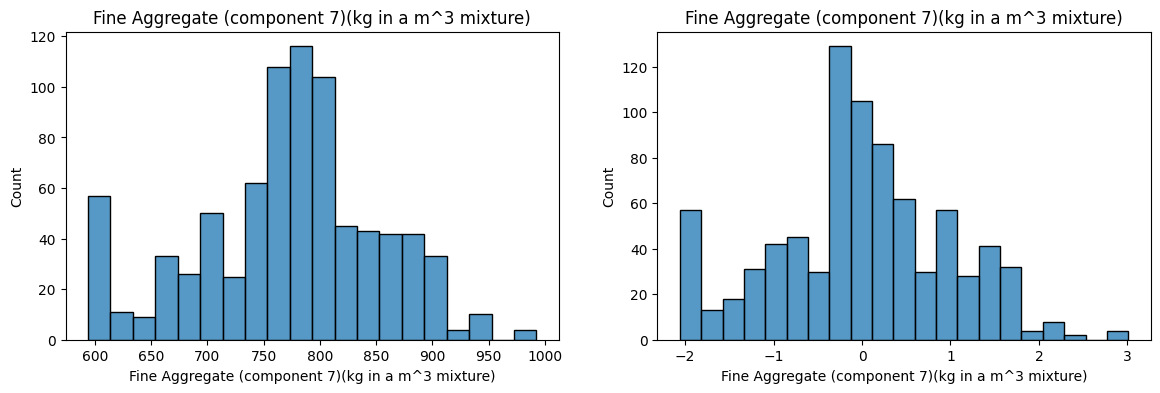

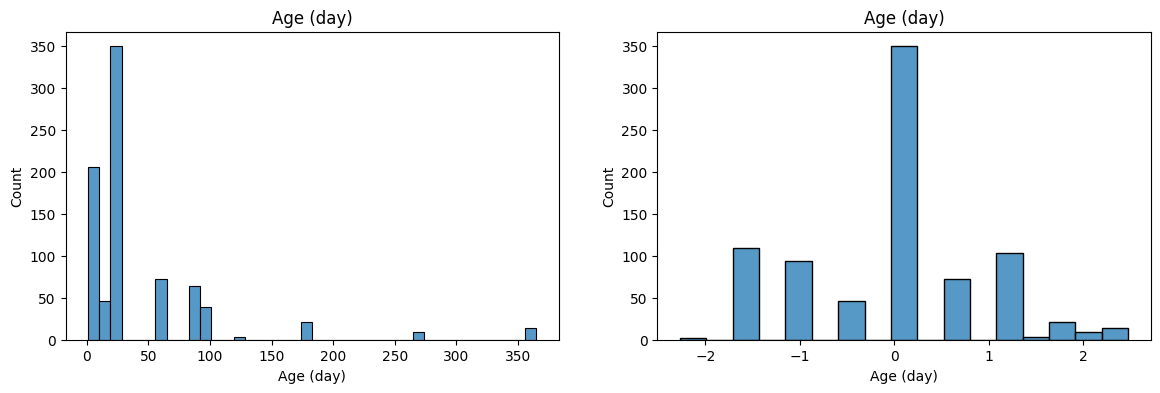

In [33]:
# Before and After comparision for Yeo_Johnson
x_train_transformed2 = pd.DataFrame(
    x_train_transformed2,
    columns=x_train.columns
)

for col in x_train_transformed2.columns:
    plt.figure(figsize=(14, 4))

    plt.subplot(121)
    sns.histplot(x_train[col])
    plt.title(col)

    plt.subplot(122)
    sns.histplot(x_train_transformed2[col])
    plt.title(col)

    plt.show()

In [35]:
# Side By Side Lambdas
pd.DataFrame({
    'cols': x_train.columns,
    'box_cox_lambdas': pt.lambdas_,
    'Yeo_Johnson_lambdas': pt1.lambdas_
})

,cols,box_cox_lambdas,Yeo_Johnson_lambdas
0,Cement (component 1)(kg in a m^3 mixture),0.169544,0.174348
1,Blast Furnace Slag (component 2)(kg in a m^3 m...,0.016633,0.015715
2,Fly Ash (component 3)(kg in a m^3 mixture),-0.136480,-0.161447
3,Water (component 4)(kg in a m^3 mixture),0.808438,0.771307
4,Superplasticizer (component 5)(kg in a m^3 mix...,0.264160,0.253935
5,Coarse Aggregate (component 6)(kg in a m^3 mi...,1.129395,1.130050
6,Fine Aggregate (component 7)(kg in a m^3 mixture),1.830764,1.783100
7,Age (day),0.001771,0.019885
